# Artificial Intelligence
## L.EIC – 3rd Year/2nd Semester
### Exercise Sheet 1
# Solving Problems by Searching

## The Two Buckets Problem

<img src="https://qph.cf2.quoracdn.net/main-qimg-45726b16b460cae0147ae8ca245a8fb0-pjlq" width="250px" height="250px" align="right">

Two buckets of capacities **c1** (e.g. 4 liters) and **c2** (e.g. 3 liters), respectively, are initially empty. The buckets do not have any intermediate markings. The only operations you can perform are:

- Fill (completely) a bucket
- Empty a bucket.
- Pour one bucket into the other until the target one is full or the source is empty.

The aim is to determine which operations to carry out so that the first bucket contains exactly **n** liters (e.g. 2 litres).

**a)** Formulate this problem as a search problem by defining the state representation, initial state, operators (their name, preconditions, effects, and cost), and final state(s).

| name          | preconditions        | effects/transitioned state | unit | tap  | waste | transition/manipulation |
| ------------- | -------------------- | -------------------------- | ---- | ---- | ----- | ----------------------- |
| empty1        | b1>0                 | (0,b2)                     | 1    | 0    | b1    | b1                      |
| empty2        | b2>0                 | (b1,0)                     | 1    | 0    | b2    | b2                      |
| fill1         | b1<4                 | (4,b2)                     | 1    | 4-b1 | 0     | 4-b1                    |
| fill2         | b2<3                 | (b1,3)                     | 1    | 3-b2 | 0     | 3-b2                    |
| pour12_fill2  | b1>0, b2<3, b1>=3-b2 | (b1-(3-b2),3)              | 1    | 0    | 0     | 3-b2                    |
| pour12_empty1 | b1>0, b2<3, b1+b2<=3 | (0, b2+b1)                 | 1    | 0    | 0     | b1                      |
| pour21_fill1  | b2>0, b1<4, b2>=4-b1 | (4, b2-(4-b1))             | 1    | 0    | 0     | 4-b1                    |
| pour21_empty2 | b2>0, b1<4, b2+b1<=4 | (b1+b2, 0)                 | 1    | 0    | 0     | b2                      |

**b)** Draw a partial state space graph with some of the possible transitions. What is the state space size for this problem? Consider only reachable states. *(Note: you might want to do this on paper and pencil.)*

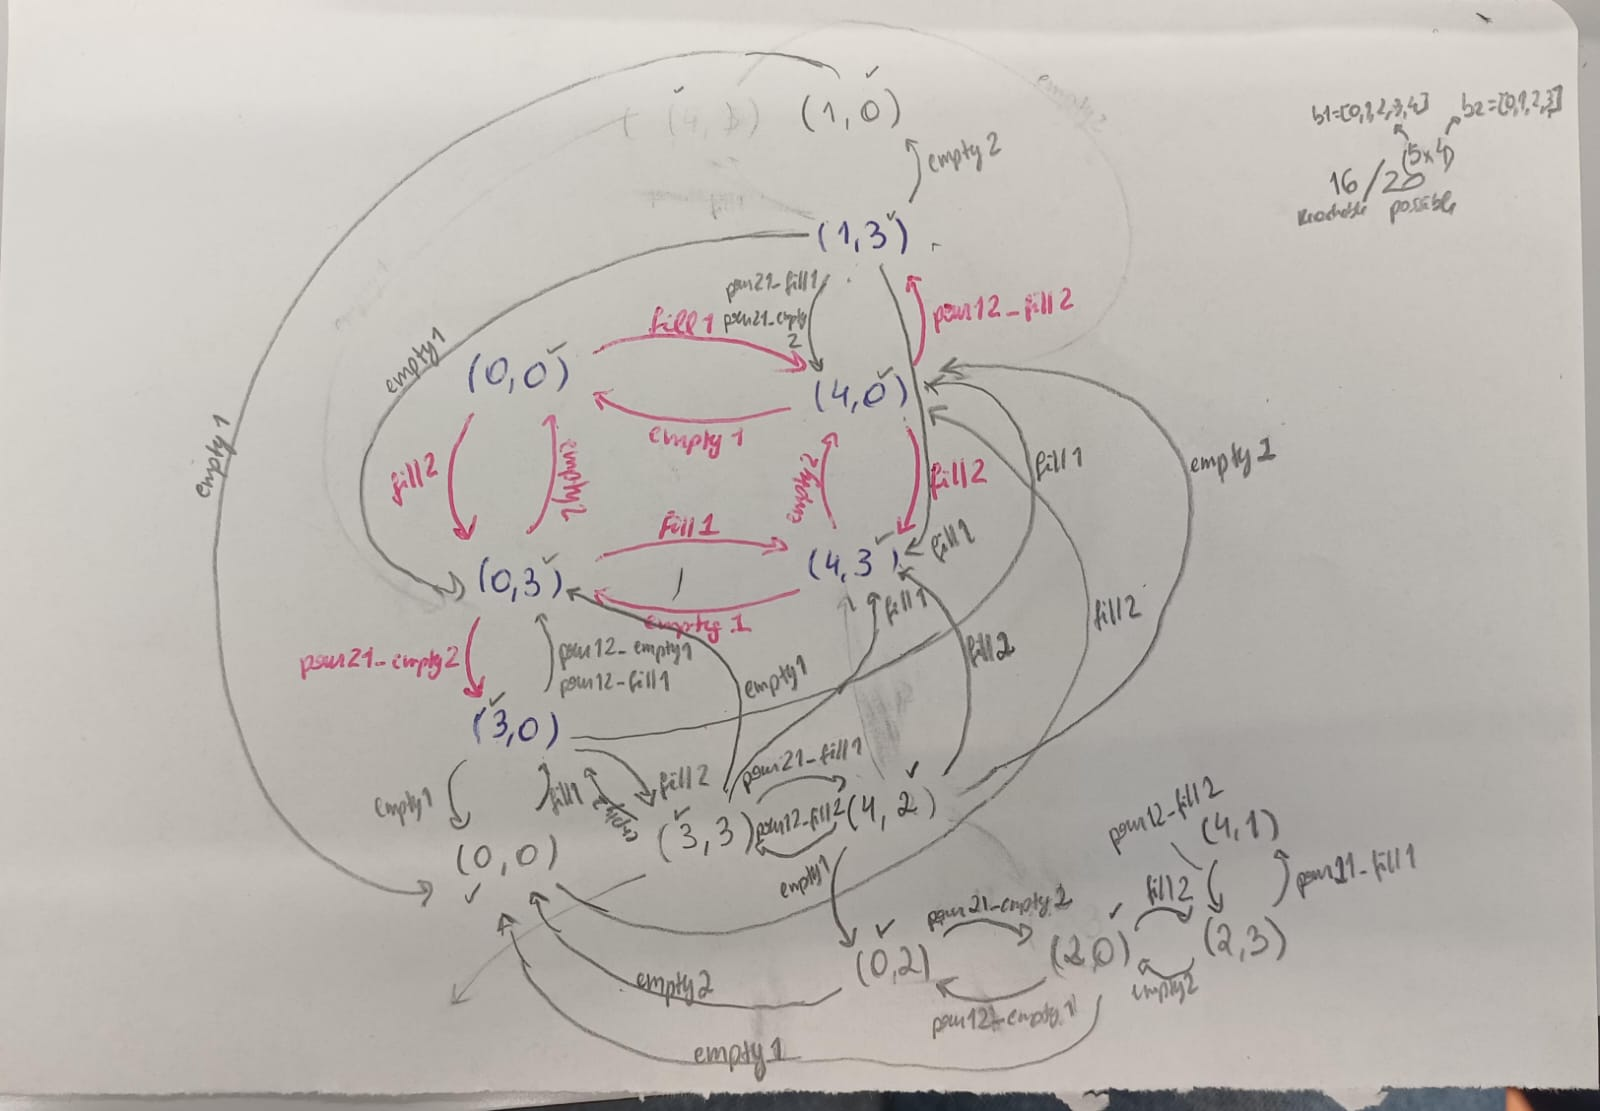

**c)** Solve the problem by hand, using a search tree. What solutions have you found?

### Buildind a computational approach to handle the problem

*(Note: this notebook suggests an implementation using Python; however, feel free to use any other programming language you like, such as Prolog ;-) .)*

To build a program to solve the buckets problem, we will implement a solution that separates the problem definition from the algorithms used to traverse the state space. This way, we can reuse our implementations of the search strategies in other problems.

#### Representing the two buckets problem as a search problem

Let's start by defining a state for the buckets problem. For that, it'll suffice to aggregate two quantities, each representing the amount of water in one of the buckets. We also define a way of printing the state.

In [ ]:
class BucketState:
    c1 = 4   # capacity for bucket 1
    c2 = 3   # capacity for bucket 2

    def __init__(self, b1, b2):
        self.b1 = b1
        self.b2 = b2

    '''needed for the visited list'''
    def __eq__(self, other):
        if isinstance(other, self.__class__):
            return self.__dict__ == other.__dict__
        else:
            return False

    def __ne__(self, other):
        """Overrides the default implementation (unnecessary in Python 3)"""
        return not self.__eq__(other)

    def __hash__(self):
        return hash((self.b1, self.b2))
    ''' - '''

    def __str__(self):
        return "(" + str(self.b1) + ", " + str(self.b2) + ")"

Now we define each of the operators on states:

In [ ]:
# emptying the first bucket
def empty1(state):
    if state.b1 > 0:
        return BucketState(0, state.b2), 1   # using unitary costs
    return None

# emptying the second bucket
def empty2(state):
    if state.b2 > 0:
        return BucketState(state.b1,0), 1
    return None


# filling the first bucket
def fill1(state):
    if state.b1 < BucketState.c1:
        return BucketState(BucketState.c1, state.b2), 1
    return None

# filling the second bucket
def fill2(state):
    # your code here




# pouring from the first to the second bucket until the target is full
def pour12_fill2(state):
    if state.b1 > 0 and state.b2 < BucketState.c2 and state.b1+state.b2 >= BucketState.c2:
        return BucketState(state.b1 - (BucketState.c2 - state.b2), BucketState.c2), 1
    return None

# pouring from the first to the second bucket until the source is empty
def pour12_empty1(state):
    # your code here




# pouring from the second to the first bucket until the target is full
def pour21_fill1(state):
    # your code here




# pouring from the second to the first bucket until the source is empty
def pour21_empty2(state):
    # your code here




The following function will aggregate all states that can be generated from a given one:

In [ ]:
def child_bucket_states(state):
    new_states = []
    if(empty1(state)):
        new_states.append(empty1(state))
    if(empty2(state)):
        new_states.append(empty2(state))
    if(fill1(state)):
        new_states.append(fill1(state))
    if(fill2(state)):
        new_states.append(fill2(state))
    if(pour12_fill2(state)):
        new_states.append(pour12_fill2(state))
    if(pour12_empty1(state)):
        new_states.append(pour12_empty1(state))
    if(pour21_fill1(state)):
        new_states.append(pour21_fill1(state))
    if(pour21_empty2(state)):
        new_states.append(pour21_empty2(state))
    return new_states

Play around with the state transition operators and check if they are working properly:

In [ ]:
s = BucketState(0, 0)
s = fill2(s)
print(s)

print()

for child, _ in child_bucket_states(BucketState(0, 0)):
    print(child)

# your code here


Finally, we need to define the goal condition:

In [ ]:
def goal_bucket_state(state):
    # your code here




Test your goal condition:

In [ ]:
# your code here




#### Implementing search algorithms

Let us start by defining an appropriate structure to represent a node in a search tree. Each tree node will include:
- a state of the problem
- a link to its parent (to allow traveling from a leaf node towards the root of the tree)
- a list of child nodes

In [ ]:
# A generic definition of a tree node holding a state of the problem
class TreeNode:
    def __init__(self, state, parent=None):
        self.state = state
        self.parent = parent
        self.children = []

    def add_child(self, child_node):
        self.children.append(child_node)
        child_node.parent = self

##### Breadth-first search

Based on this structure, we can now implement breadth-first search. Note that we want the implementation to be independent of the problem at hand (in this case, the two buckets problem).

In [ ]:
from collections import deque

def breadth_first_search(initial_state, goal_state_func, operators_func):
    root = TreeNode(initial_state)   # create the root node in the search tree
    queue = deque([root])   # initialize the queue to store the nodes

    while queue:
        node = queue.popleft()   # get first element in the queue
        if goal_state_func(node.state):   # check goal state
            return node

        for state, _ in operators_func(node.state):   # go through next states
            # create tree node with the new state
            # your code here


            # link child node to its parent in the tree
            # your code here


            # enqueue the child node
            # your code here


    return None

We can now use this function to actually perform a breadth-first search on the buckets problem: we pass it the initial state, our goal condition function, and the function for obtaining child states.

In [ ]:
goal = breadth_first_search(BucketState(0,0),
                            goal_bucket_state,
                            child_bucket_states)
print(goal.state)

In order to print the actual steps from the initial state to the last, we can take advantage of each node's link to its parent.

In [ ]:
def print_solution(node):
    # your code here








    return

Now we can print the solution:

In [ ]:
print_solution(goal)

If we need a description for each of the employed operators, we could have each operation function return also such a description, and modify the TreeNode class so that each node also includes a description of the edge to get there. We leave that as an exercise after class.

##### Depth-first search

Implement depth-first search (again, in a manner that is independent of the problem at hand). You can start from your breadth-first search implementation and with minor changes get an implementation for depth-first search.

In [ ]:
def depth_first_search(initial_state, goal_state_func, operators_func):
    # your code here


















Test it on the two buckets problem.

In [ ]:
# your code here






If you are unable to get a solution, think about it: depth-first search is not a complete search method, and one of the reasons for that is if the state space contains cycles. As such, you need to make sure you avoid entering into a cycle by keeping a visited nodes list or set and checking that list whenever you generate a new state.

##### Depth-limited search

Another way to make it work is to impose a depth limit to the problem. Implement depth-limited search.

In [ ]:
def depth_limited_search(initial_state, goal_state_func, operators_func, depth_limit):
    # your code here














Test it on the two buckets problem.

In [ ]:
# your code here







##### Iterative deepening search

Based on depth-limited, you can easily implement iterative-deepening search.

In [ ]:
def iterative_deepening_search(initial_state, goal_state_func, operators_func, depth_limit):
    # your code here





Again, test it on the two buckets problem.

In [ ]:
# your code here







## The Missionaries and Cannibals Problem

<img src="https://allfish24.files.wordpress.com/2016/09/gambar-1.jpg">

Three missionaries and three cannibals are on one of the banks of the river with a boat that only takes one or two people. The boat cannot travel the river alone.

The goal is to find a way to get the six to the other bank of the river without ever having more cannibals than missionaries on one of the banks (even at the instant they leave/join the boat) during the process.

**a)** Formulate this problem as a search problem by defining the state representation, initial state, operators (their name, preconditions, effects, and cost), and final state(s).

**b)** Draw a partial state space graph with some of the possible transitions. What is the state space size for this problem? Consider only reachable states. *(Note: you might want to do this on paper and pencil.)*

**c)** Solve the problem by hand, using a search tree. What solutions have you found?

**d)** Make your own implementation of the problem as a search problem and take advantage of the implemented search algorithms to find solutions.

In [ ]:
class MisCanState:

    def __init__(self, mis, can, boat):
        self.mis = mis   # number of missionaries on the initial bank
        self.can = can   # number of canibals on the initial bank
        self.boat = boat   # boat on the initial bank?

    '''needed for the visited list'''
    def __eq__(self, other):
        if isinstance(other, self.__class__):
            return self.__dict__ == other.__dict__
        else:
            return False

    def __ne__(self, other):
        """Overrides the default implementation (unnecessary in Python 3)"""
        return not self.__eq__(other)

    def __hash__(self):
        return hash((self.mis, self.can, self.boat))
    ''' - '''

    def __str__(self):
        return "(" + str(self.mis) + ", " + str(self.can) + ", " + str(self.boat) + ")"

In [ ]:
# your code here







